In [1]:
import matplotlib.pyplot as plt
#from src.TimeSeriesAnalysis import *
#from src.process_data import summarize_all_dirs, create_folder, process_all_data
from IPython.display import clear_output
from src.TimeSeriesAnalysis import load_properties_bundle, create_folder
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, LinearLocator,FormatStrFormatter
from matplotlib.lines import Line2D
#from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from tqdm import tqdm
import pandas as pd
import os
import numpy as np

In [2]:
results = "../results/article_plots/"
create_folder(results)

## Time Series $n_s$ for $L = 1024$

KeyError: nc=1, L=1024, c=0.05, fT=0.02591667, p0=0.3
KeyError: nc=2, L=1024, c=0.05, fT=0.02591667, p0=0.7
KeyError: nc=4, L=1024, c=0.05, fT=0.02591667, p0=1.0
KeyError: nc=1, L=1024, c=0.05, fT=0.009305553, p0=0.3
KeyError: nc=2, L=1024, c=0.05, fT=0.009305553, p0=0.7
KeyError: nc=4, L=1024, c=0.05, fT=0.009305553, p0=1.0
KeyError: nc=1, L=1024, c=0.05, fT=0.008786, p0=0.3
KeyError: nc=2, L=1024, c=0.05, fT=0.008786, p0=0.7
KeyError: nc=4, L=1024, c=0.05, fT=0.008786, p0=1.0
KeyError: nc=1, L=1024, c=0.05, fT=0.00671, p0=0.3
KeyError: nc=2, L=1024, c=0.05, fT=0.00671, p0=0.7
KeyError: nc=4, L=1024, c=0.05, fT=0.00671, p0=1.0


/tmp/ipykernel_11412/1629221881.py:69: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, t_max)
/tmp/ipykernel_11412/1629221881.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(


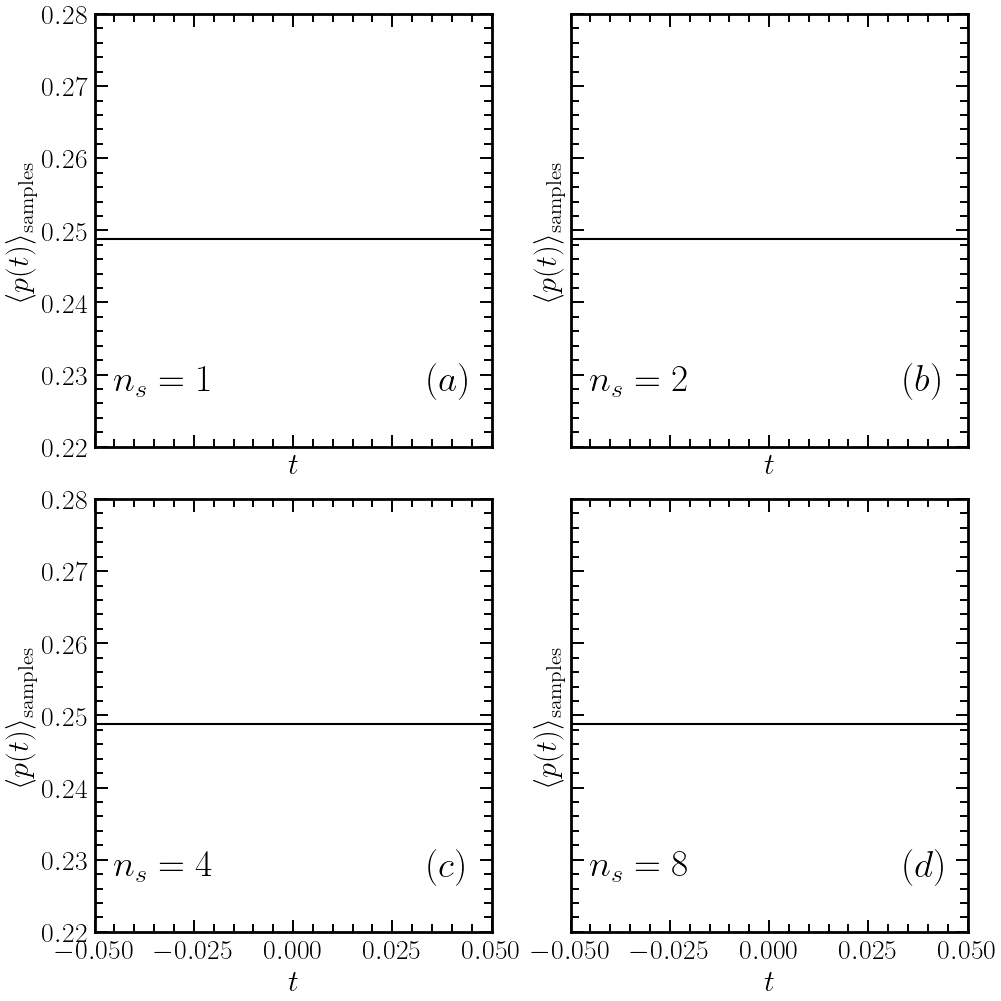

In [ ]:
# pt_mean vs time for different p0 and nc, for c=0.05, L=1024, dim=3
nc_lst = [1,2,4,8]
p0_lst = [0.3, 0.7, 1.0]
L = 1024
c = 0.05
dim = 3
p0 = 0.6
base = 10
fig, axes = plt.subplots(2, 2, figsize=(base, base), sharex=True, sharey=True, constrained_layout=True)

fs_legend = 19
fs_labels_fig = 27
fs_labels = 22
t_max = 0
colors = [
    (0.90, 0.10, 0.10),  # red
    (0.00, 0.60, 0.30),  # green
    (0.10, 0.10, 0.90),  # blue
]
labels_fig = [
    r'$(a)$', r'$(b)$', r'$(c)$', r'$(d)$']

pc = 0.24881182
df_ft_common = pd.read_csv("../SOP_data/f_T_common.csv")
order_mean = 0

for idx, ax in enumerate(axes.flatten()):
    fT = df_ft_common[(df_ft_common["nc"] == nc_lst[idx]) & (df_ft_common["c"] == c)]["f_T_min_common"].values[0]
    rho = 1/nc_lst[idx]
    
    path = (
        f"../SOP_data/published/bond_percolation/"
        f"num_colors_{nc_lst[idx]}/dim_{dim}/L_{L}/"
        f"fT_constant/fT_{fT:.6e}/"
        f"c_{c:.6e}/rho_{rho:.4e}"
    )

    fn = path + "/properties_mean_bundle.json"

    try:
        bundle = load_properties_bundle(fn)
        for idx, p0 in enumerate(p0_lst):    
            try:
                data = bundle[p0]["orders"][order_mean]

            except KeyError:
                print(f"KeyError: nc={nc_lst[idx]}, L={L}, c={c}, fT={fT}, p0={p0}")
                continue
            
            time = data["time"]
            pt_mean = data["pt_mean"]
            t_max = max(t_max, max(time))
            ax.plot(
                time,
                pt_mean,
                ls='solid',
                lw = 1.4,
                color=colors[idx],
                label=fr"$p_0 = {p0}$"
            )
    except FileNotFoundError:
        print(f"File not found: {fn}")
        continue
    if(idx==0  or idx==2):
        ax.set_ylabel(r'$\langle p(t) \rangle_{\mathrm{samples}}$',fontsize=fs_labels)
    if(idx==2 or idx==3):
        ax.set_xlabel(r'$t$',fontsize=fs_labels)

for idx, ax in enumerate(axes.flatten()):
    ax.set_ylim(0.22, 0.28)
    ax.set_xlim(0, t_max)
    ax.text(
        0.84,
        0.13,
        labels_fig[idx],
        transform=ax.transAxes,
        fontsize=fs_labels_fig
    )

    ax.text(
        0.05,
        0.13,
        f"$n_s = {nc_lst[idx]}$",
        transform=ax.transAxes,
        fontsize=fs_labels_fig
    )
    leg = ax.legend(
        fontsize=fs_legend,
        handlelength=1.8,
        handletextpad=0.6,
        borderpad=0.4,
        labelspacing=0.4
    )

    for line in leg.get_lines():
        line.set_linewidth(2.0)
    ax.axhline(pc, color='k', ls='solid')
#plt.savefig(f"{results}/TimeSeries_L.png", dpi=300)
plt.show()

In [ ]:
# fT_mean vs time for different p0 and nc, for c=0.05, L=1024, dim=3
nc_lst = [1,2,4,8]
p0_lst = [0.3, 0.7, 1.0]
L = 1024
c = 0.05
dim = 3
p0 = 0.6
base = 10
fig, axes = plt.subplots(2, 2, figsize=(base, base), sharex=True, sharey=True, constrained_layout=True)

fs_legend = 19
fs_labels_fig = 27
fs_labels = 22
t_max = 0
colors = [
    (0.90, 0.10, 0.10),  # red
    (0.00, 0.60, 0.30),  # green
    (0.10, 0.10, 0.90),  # blue
]
labels_fig = [
    r'$(a)$', r'$(b)$', r'$(c)$', r'$(d)$']

pc = 0.24881182
df_ft_common = pd.read_csv("../SOP_data/f_T_common.csv")
order_mean = 0

for idx, ax in enumerate(axes.flatten()):
    fT = df_ft_common[(df_ft_common["nc"] == nc_lst[idx]) & (df_ft_common["c"] == c)]["f_T_min_common"].values[0]
    rho = 1/nc_lst[idx]
    
    path = (
        f"../SOP_data/published/bond_percolation/"
        f"num_colors_{nc_lst[idx]}/dim_{dim}/L_{L}/"
        f"fT_constant/fT_{fT:.6e}/"
        f"c_{c:.6e}/rho_{rho:.4e}"
    )

    fn = path + "/properties_mean_bundle.json"

    try:
        bundle = load_properties_bundle(fn)
        for idx, p0 in enumerate(p0_lst):    
            try:
                data = bundle[p0]["orders"][order_mean]

            except KeyError:
                print(f"KeyError: nc={nc_lst[idx]}, L={L}, c={c}, fT={fT}, p0={p0}")
                continue
            
            time = data["time"]
            pt_mean = data["pt_mean"]
            t_max = max(t_max, max(time))
            ax.plot(
                time,
                pt_mean,
                ls='solid',
                lw = 1.4,
                color=colors[idx],
                label=fr"$p_0 = {p0}$"
            )
    except FileNotFoundError:
        print(f"File not found: {fn}")
        continue
    
    if(idx==0  or idx==2):
        ax.set_ylabel(r'$\langle f(t) \rangle_{\mathrm{samples}}$',fontsize=fs_labels)
    if(idx==2 or idx==3):
        ax.set_xlabel(r'$t$',fontsize=fs_labels)

for idx, ax in enumerate(axes.flatten()):
    ax.set_xlim(0, t_max)
    ax.text(
        0.84,
        0.13,
        labels_fig[idx],
        transform=ax.transAxes,
        fontsize=fs_labels_fig
    )

    ax.text(
        0.05,
        0.13,
        f"$n_s = {nc_lst[idx]}$",
        transform=ax.transAxes,
        fontsize=fs_labels_fig
    )
    leg = ax.legend(
        fontsize=fs_legend,
        handlelength=1.8,
        handletextpad=0.6,
        borderpad=0.4,
        labelspacing=0.4
    )

    for line in leg.get_lines():
        line.set_linewidth(2.0)
    fT = df_ft_common[(df_ft_common["nc"] == nc_lst[idx]) & (df_ft_common["c"] == c)]["f_T_min_common"].values[0]
    ax.axhline(fT, color='k', ls='solid')
#plt.savefig(f"{results}/TimeSeries_L.png", dpi=300)
plt.show()